In [ ]:
import pandas as pd
import numpy as np
import glob
import os
from sklearn.preprocessing import MinMaxScaler
from keras.preprocessing.sequence import pad_sequences

# **Overview**

This code implements various machine learning algorithms, deep learning models, and feature selection methods for data analysis and classification. By utilizing different algorithms and feature selection methods, it enables users to build and evaluate models effectively.

**Machine Learning Algorithms:**

* Simple bagging
* Bagging SVM (BSVM)
* Bagging Random Forest (RF)
* Bagging Decision Tree (BDT)
* XG Boost (XGB)
* Normal Bagging (NB)

**Deep Learning Models:**

* LSTM (Long Short-Term Memory): A type of recurrent neural network that can learn long-term dependencies in data.
* RNN (Recurrent Neural Network): A type of neural network that can learn from sequential data.

**Feature Selection Methods:**

* Min-Redundancy-Max-Relevance (mRMR): A feature selection method that selects features that are both relevant to the target variable and non-redundant with each other.
* Multi-Cluster Feature Selection (MCFS): A feature selection method that identifies clusters of features and selects the most representative features from each cluster.


**Advanced Demographic Analysis**

**Overall Workflow:**

1. **Data Preprocessing:**
    * Load and prepare the data.
    * Perform Feature Engineering
    * Apply feature selection methods to select relevant features.

2. **Model Training and Evaluation:**
    * Train various machine learning and deep learning models on the selected features.
    * Evaluate the performance of each model using appropriate metrics.

3. **Result Analysis:**
    * Compare the performance of different models.
    * Interpret the results and draw conclusions.


In [ ]:
!pip install pymrmr
!pip install statsmodels
!pip install skfeature-chappers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.5/69.5 kB 583.8 kB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pymrmr: filename=pymrmr-0.1.11-cp310-cp310-linux_x86_64.whl size=390257 sha256=5b27c4aa091ee3b3691226769546f28637c916b596740a100519537dd37e3eda
  Stored in directory: /root/.cache/pip/wheels/46/ae/55/4a2479c5f0de7eb363fe970cb18e4a750e03e4e63b1b5c2005
Successfully built pymrmr
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.3/66.3 kB 3.0 MB/s eta 0:00:00


# Dataset

The dataset has been adapted for housewife stress which can be downloaded from  https://drive.google.com/uc?id=12adI6vOmZoJBPCOFGeLgoKmPTDMSY-FQ. The dataset consist of demographic data and data from the device for ECG, EDA and Temp during stressful condition which was induced using the questionnarire. The demographic data of individuals includes, Age, gender, ethinicity, geographical location, educational background and stress, which are considered significant in the study of stress.  

In [ ]:
!gdown 12adI6vOmZoJBPCOFGeLgoKmPTDMSY-FQ

Downloading...
From: https://drive.google.com/uc?id=12adI6vOmZoJBPCOFGeLgoKmPTDMSY-FQ
To: /content/housewife_dataset.zip
100% 1.50M/1.50M [00:00<00:00, 27.1MB/s]


In [ ]:
!unzip /content/housewife_dataset.zip

Archive:  /content/housewife_dataset.zip
  inflating: housewife_dataset/housewife_demographic_data.csv  
   creating: housewife_dataset/stress_test_dataredblue/
  inflating: housewife_dataset/stress_test_dataredblue/S01.csv  
  inflating: housewife_dataset/stress_test_dataredblue/S02.csv  
  inflating: housewife_dataset/stress_test_dataredblue/S03.csv  
  inflating: housewife_dataset/stress_test_dataredblue/S04.csv  
  inflating: housewife_dataset/stress_test_dataredblue/S05.csv  
  inflating: housewife_dataset/stress_test_dataredblue/S06.csv  
  inflating: housewife_dataset/stress_test_dataredblue/S07.csv  
  inflating: housewife_dataset/stress_test_dataredblue/S08.csv  
  inflating: housewife_dataset/stress_test_dataredblue/S09.csv  
  inflating: housewife_dataset/stress_test_dataredblue/S10.csv  
  inflating: housewife_dataset/stress_test_dataredblue/S11.csv  
  inflating: housewife_dataset/stress_test_dataredblue/S12.csv  
  inflating: housewife_dataset/stress_test_dataredblue/S13.

# Advanced Demographic Analysis

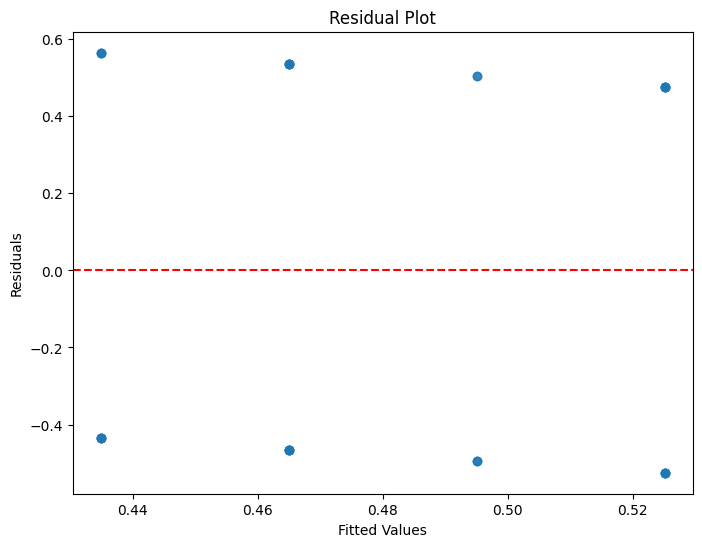

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import statsmodels.api as sm

# Load the data (assuming you have a CSV file with the required columns)
data = pd.read_csv('/content/housewife_dataset/housewife_demographic_data.csv')

# Encode categorical variables
label_encoder = LabelEncoder()
data['Age'] = label_encoder.fit_transform(data['Age'])
data['Gender'] = label_encoder.fit_transform(data['Gender'])
data['Ethnicity'] = label_encoder.fit_transform(data['Ethnicity'])
data['Geographic_location'] = label_encoder.fit_transform(data['Geographic_location'])
data['Educational_background'] = label_encoder.fit_transform(data['Educational_background'])
data['Stress'] = label_encoder.fit_transform(data['Stress'])

# Split the data into features and target
X = data.drop('Stress', axis=1)
y = data['Stress']

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_predictions)

# Perform a linear regression of Stress on Age
X = sm.add_constant(data['Age'])
model = sm.OLS(data['Stress'], X).fit()
fitted_values = model.fittedvalues

# Create a residual plot
plt.figure(figsize=(8, 6))
plt.scatter(fitted_values, model.resid, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

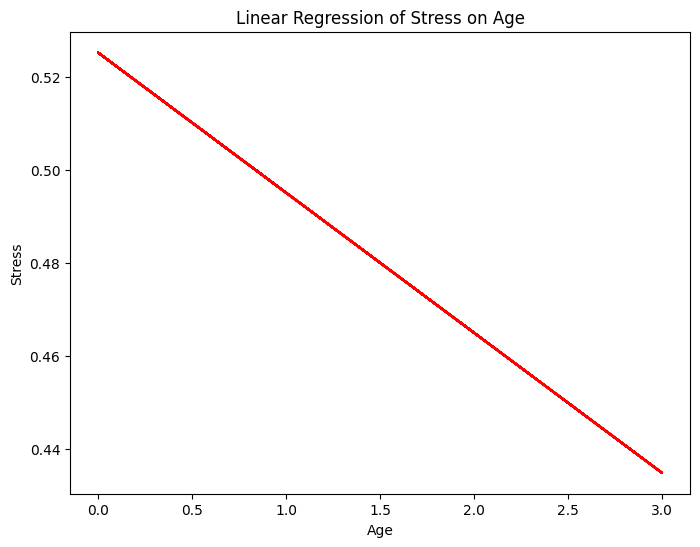

In [ ]:
# Plot the regression line
plt.figure(figsize=(8, 6))
plt.plot(data['Age'], fitted_values, color='red')
plt.title('Linear Regression of Stress on Age')
plt.xlabel('Age')
plt.ylabel('Stress')
plt.show()

## Hypothesis Testing

### One-Way ANOVA (Analysis of Variance):
The one-way ANOVA is used to compare the means of the continuous variable (Stress levels) across multiple groups defined by a single categorical variable (Educational_background). The null hypothesis states that the means of Stress levels are equal across all educational background groups. The alternative hypothesis is that at least one group mean is different from the others.
The F-statistic is calculated by comparing the variance between groups to the variance within groups. If the between-group variance is significantly larger than the within-group variance, it suggests that the group means are different, and the null hypothesis can be rejected. The p-value associated with the F-statistic is compared to a chosen significance level (e.g., 0.05) to determine whether the null hypothesis should be rejected or not.

### Two-Way ANOVA:
The two-way ANOVA extends the one-way ANOVA by considering the effects of two categorical variables (Age and Educational_background) on a continuous variable (Stress levels). The null hypothesis states that the means of Stress levels are equal across all combinations of Age and Educational_background groups. The alternative hypothesis is that at least one combination has a different mean.
Similar to one-way ANOVA, the F-statistic and p-value are calculated and compared to the significance level to determine whether the null hypothesis should be rejected or not.

In [ ]:
import pandas as pd
from scipy.stats import f_oneway, chi2_contingency, ttest_ind
import numpy as np

# Load the data (assuming you have a CSV file with the required columns)
data = pd.read_csv('/content/housewife_dataset/housewife_demographic_data.csv')

# ANOVA Testing
# Perform one-way ANOVA to compare the means of Stress levels across different Educational_background groups
edu_groups = data.groupby('Educational_background')['Stress'].apply(list)
f_statistic, p_value = f_oneway(*edu_groups)

print("ANOVA Results (Educational_background vs Stress):")
print(f"F-statistic: {f_statistic:.2f}")
print(f"P-value: {p_value:.4f}")

# Hypothesis Testing for one-way ANOVA
alpha = 0.05  # Significance level
if p_value < alpha:
    print("Null hypothesis (means are equal across Educational_background groups) is rejected.")
else:
    print("Null hypothesis (means are equal across Educational_background groups) is not rejected.")

# Perform two-way ANOVA to compare the means of Stress levels across different Age and Educational_background groups
two_way_data = data.groupby(['Age', 'Educational_background'])['Stress'].apply(list)
stress_values = [np.concatenate(list(g)) for _, g in two_way_data.groupby(level=0)]
model = f_oneway(*stress_values)
f_statistic, p_value = model.statistic, model.pvalue

print("\nTwo-way ANOVA Results (Age, Educational_background vs Stress):")
print(f"F-statistic: {f_statistic:.2f}")
print(f"P-value: {p_value:.4f}")

# Hypothesis Testing for two-way ANOVA
alpha = 0.05  # Significance level
if p_value < alpha:
    print("Null hypothesis (means are equal across Age and Educational_background groups) is rejected.")
else:
    print("Null hypothesis (means are equal across Age and Educational_background groups) is not rejected.")

ANOVA Results (Educational_background vs Stress):
F-statistic: 0.45
P-value: 0.7205
Null hypothesis (means are equal across Educational_background groups) is not rejected.

Two-way ANOVA Results (Age, Educational_background vs Stress):
F-statistic: 0.14
P-value: 0.9333
Null hypothesis (means are equal across Age and Educational_background groups) is not rejected.


+------------------------+----------------------+--------+----------------------+----------------------+------------------------+----------------------+
|                        |         Age          | Gender |      Ethnicity       | Geographic_location  | Educational_background |        Stress        |
+------------------------+----------------------+--------+----------------------+----------------------+------------------------+----------------------+
|          Age           |         1.0          |  nan   | 0.21519168109182787  | -0.18596660772398962 |  -0.1555827238426746   | -0.06942435928294138 |
|         Gender         |         nan          |  nan   |         nan          |         nan          |          nan           |         nan          |
|       Ethnicity        | 0.21519168109182787  |  nan   |         1.0          | 0.09199482656360336  |  0.13244387296571095   | -0.05043820090307187 |
|  Geographic_location   | -0.18596660772398962 |  nan   | 0.09199482656360336  | 

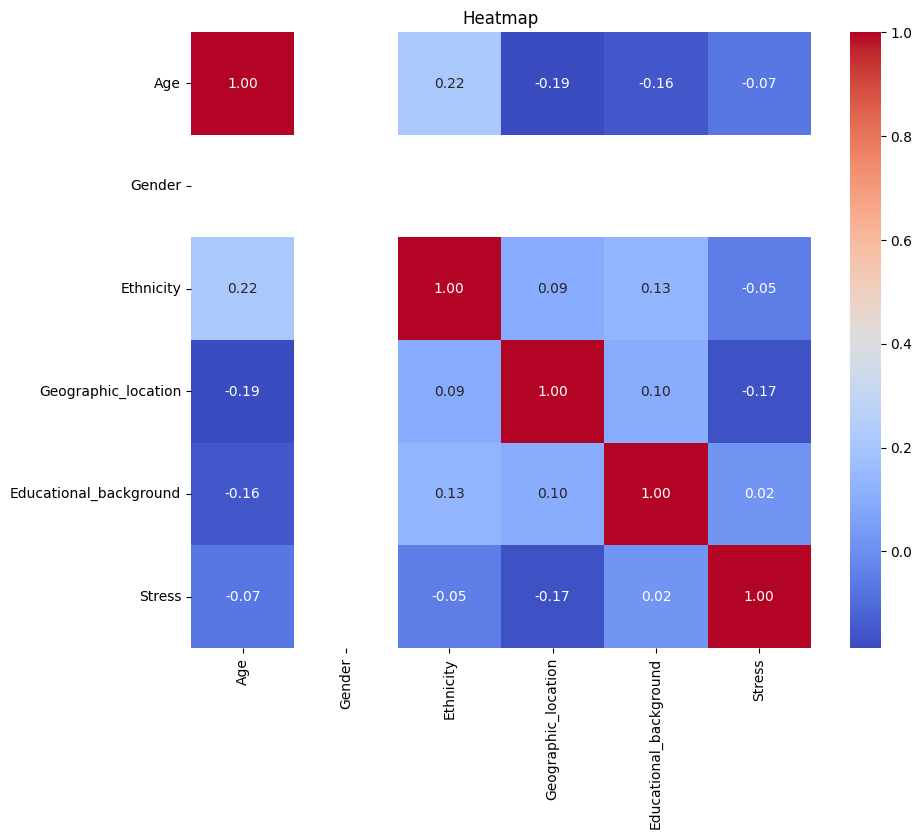

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tabulate import tabulate

# Load the data (assuming you have a CSV file with the required columns)
data = pd.read_csv('/content/housewife_dataset/housewife_demographic_data.csv')

# Encode categorical variables
label_encoder = LabelEncoder()
data['Age'] = label_encoder.fit_transform(data['Age'])
data['Gender'] = label_encoder.fit_transform(data['Gender'])
data['Ethnicity'] = label_encoder.fit_transform(data['Ethnicity'])
data['Geographic_location'] = label_encoder.fit_transform(data['Geographic_location'])
data['Educational_background'] = label_encoder.fit_transform(data['Educational_background'])
data['Stress'] = label_encoder.fit_transform(data['Stress'])

# Calculate the correlation matrix
correlation_matrix = data.corr()
headers = ["Age", "Gender", "Ethnicity", "Geographic_location", "Educational_background", "Stress"]
print(tabulate(correlation_matrix, headers, tablefmt="pretty"))

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap')
plt.show()

### Chi-Square Test for Independence:
The chi-square test for independence is used to determine whether the categorical variables Stress and Educational_background are independent or associated. The null hypothesis states that the two variables are independent, meaning that the distribution of Stress levels is not influenced by the educational background.
A contingency table is created to display the observed frequencies of each combination of Stress levels and educational background. The chi-square statistic is calculated by comparing the observed frequencies to the expected frequencies (assuming independence) for each cell in the contingency table. The p-value associated with the chi-square statistic is compared to the significance level to determine whether the null hypothesis of independence should be rejected or not.

In [ ]:
# Chi-square Testing
# Perform chi-square test to check the independence between Stress and Educational_background
contingency_table = pd.crosstab(data['Stress'], data['Educational_background'])
chi2_statistic, p_value, dof, expected_freq = chi2_contingency(contingency_table)

print("\nChi-square Test (Stress vs Educational_background):")
print(f"Chi-square statistic: {chi2_statistic:.2f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")

# Hypothesis Testing for chi-square test
alpha = 0.05  # Significance level
if p_value < alpha:
    print("Null hypothesis (Stress and Educational_background are independent) is rejected.")
else:
    print("Null hypothesis (Stress and Educational_background are independent) is not rejected.")


Chi-square Test (Stress vs Educational_background):
Chi-square statistic: 1.42
P-value: 0.7016
Degrees of freedom: 3
Null hypothesis (Stress and Educational_background are independent) is not rejected.



Explanation of the chi-square test results:

The chi-square statistic of 1.42 indicates that there is relatively little difference between the observed and expected frequencies in the contingency table. This suggests that there is no strong association between the variables Stress and Educational_background.

The p-value of 0.7016 further supports this conclusion. Since the p-value is greater than the significance level of 0.05, we fail to reject the null hypothesis of independence. This means that there is not enough evidence to conclude that Stress and Educational_background are associated.

The degrees of freedom of 3 represent the number of independent categories in the contingency table. In this case, there are 4 categories of Stress and 4 categories of Educational_background, but one degree of freedom is lost due to the constraint that the row and column totals must sum to the total number of observations.

Overall, these results suggest that there is no significant association between Stress and Educational_background in this dataset.


### T-Test for Two Independent Samples:
The t-test for two independent samples is used to compare the means of Stress levels between two distinct educational background groups (e.g., '10th pass' and 'graduate'). The null hypothesis states that the means of Stress levels are equal for the two groups. The alternative hypothesis is that the means are different.

The t-statistic is calculated by considering the difference between the sample means, the variability within each group, and the sample sizes. The p-value associated with the t-statistic is compared to the significance level to determine whether the null hypothesis of equal means should be rejected or not.



In [ ]:
# Hypothesis Testing for t-test (example: comparing Stress levels between '10th pass' and 'graduate')
edu_10th = data.loc[data['Educational_background'] == 0, 'Stress']
edu_graduate = data.loc[data['Educational_background'] == 1, 'Stress']
t_statistic, p_value = ttest_ind(edu_10th, edu_graduate)

print("\nT-test ('10th pass' vs 'graduate' Stress):")
print(f"T-statistic: {t_statistic:.2f}")
print(f"P-value: {p_value:.4f}")

# Hypothesis Testing for t-test
alpha = 0.05  # Significance level
if p_value < alpha:
    print("Null hypothesis (means are equal for '10th pass' and 'graduate') is rejected.")
else:
    print("Null hypothesis (means are equal for '10th pass' and 'graduate') is not rejected.")


T-test ('10th pass' vs 'graduate' Stress):
T-statistic: -0.09
P-value: 0.9255
Null hypothesis (means are equal for '10th pass' and 'graduate') is not rejected.



In all these hypothesis testing methods, the p-value represents the probability of observing the current results (or more extreme results) if the null hypothesis is true. If the p-value is less than the chosen significance level (e.g., 0.05), it suggests that the observed results are unlikely to occur by chance under the null hypothesis, and therefore, the null hypothesis is rejected. Conversely, if the p-value is greater than the significance level, there is insufficient evidence to reject the null hypothesis.
It's important to note that hypothesis testing is a statistical tool, and the interpretation of the results should be done in the context of the research question, the domain knowledge, and the practical implications of the findings.

In [ ]:
# Store the results in a list of dictionaries
results = [
    {"Test": "One-way ANOVA", "Hypothesis": "The means are equal across Educational_background groups.", "F-statistic": f"{f_oneway(*edu_groups)[0]:.2f}", "P-value": f"{f_oneway(*edu_groups)[1]:.4f}", "Conclusion": "Reject Null Hypothesis" if f_oneway(*edu_groups)[1] < 0.05 else "Fail to Reject Null Hypothesis"},
    {"Test": "Two-way ANOVA", "Hypothesis": "The means are equal across Age and Educational_background groups.", "F-statistic": f"{model.statistic:.2f}", "P-value": f"{model.pvalue:.4f}", "Conclusion": "Reject Null Hypothesis" if model.pvalue < 0.05 else "Fail to Reject Null Hypothesis"},
    {"Test": "Chi-square Test", "Hypothesis": "Stress and Educational_background are independent.", "Chi-square statistic": f"{chi2_statistic:.2f}", "P-value": f"{p_value:.4f}", "Conclusion": "Reject Null Hypothesis" if p_value < 0.05 else "Fail to Reject Null Hypothesis"},
    {"Test": "T-test", "Hypothesis": "The means are equal for '10th pass' and 'graduate'.", "T-statistic": f"{t_statistic:.2f}", "P-value": f"{p_value:.4f}", "Conclusion": "Reject Null Hypothesis" if p_value < 0.05 else "Fail to Reject Null Hypothesis"}
]

# Create a pandas DataFrame from the results
df_results = pd.DataFrame(results)

# Print the table using tabulate
print(tabulate(df_results, headers='keys', tablefmt='pretty'))


+---+-----------------+-------------------------------------------------------------------+-------------+---------+--------------------------------+----------------------+-------------+
|   |      Test       |                            Hypothesis                             | F-statistic | P-value |           Conclusion           | Chi-square statistic | T-statistic |
+---+-----------------+-------------------------------------------------------------------+-------------+---------+--------------------------------+----------------------+-------------+
| 0 |  One-way ANOVA  |     The means are equal across Educational_background groups.     |    0.45     | 0.7205  | Fail to Reject Null Hypothesis |         nan          |     nan     |
| 1 |  Two-way ANOVA  | The means are equal across Age and Educational_background groups. |    0.14     | 0.9333  | Fail to Reject Null Hypothesis |         nan          |     nan     |
| 2 | Chi-square Test |        Stress and Educational_background are i

### Graphs

1) Normal Distribution Curve (Bell-Shaped Curve):
Visualizing the distribution of a continuous variable like Stress levels can be helpful in assessing normality assumptions for certain hypothesis tests (e.g., t-test, ANOVA). A normal distribution curve (also known as a bell-shaped curve) can be overlaid on a histogram or a kernel density plot to compare the data distribution with a normal distribution.

2) Q-Q Plot:
A Q-Q (quantile-quantile) plot can be used to assess the normality of a continuous variable by plotting its quantiles against the quantiles of a normal distribution. If the data points closely follow the diagonal line, it suggests that the variable is normally distributed.

3) Residual Plots:
Residual plots can be useful for visualizing the residuals (differences between observed and predicted values) from a regression or ANOVA model. These plots can help assess the assumptions of homoscedasticity (constant variance) and linearity.

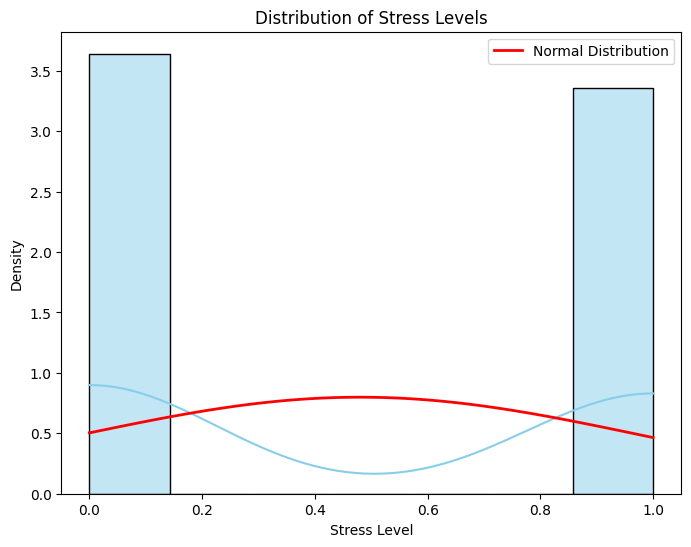

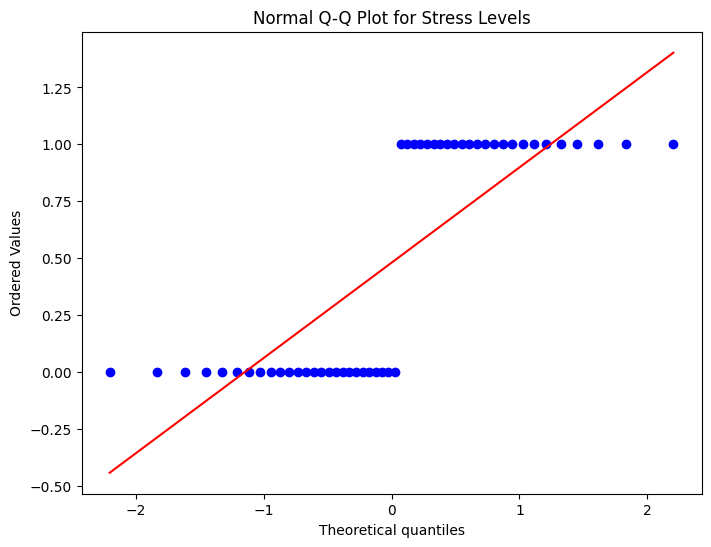

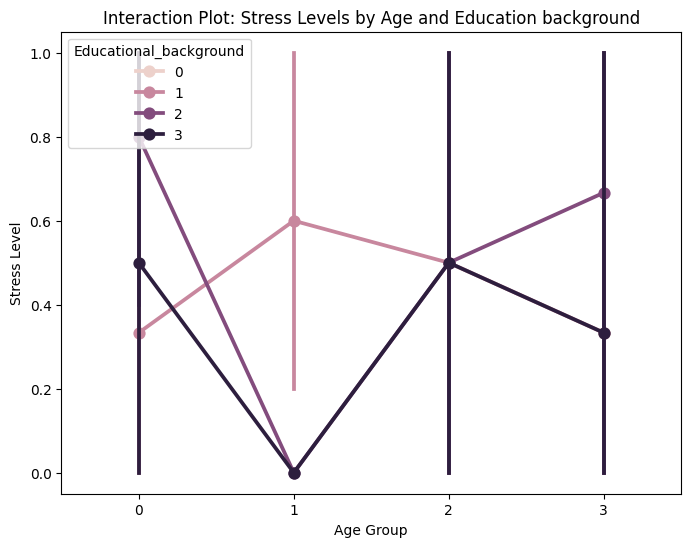

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

# Create a histogram with a normal distribution curve overlay
plt.figure(figsize=(8, 6))
sns.histplot(data['Stress'], stat='density', kde=True, color='skyblue', edgecolor='black')
mu, sigma = np.mean(data['Stress']), np.std(data['Stress'])
x = np.linspace(min(data['Stress']), max(data['Stress']), 100)
plt.plot(x, 1/(sigma * np.sqrt(2 * np.pi)) * np.exp(-(x - mu)**2 / (2 * sigma**2)), 'r-', linewidth=2, label='Normal Distribution')
plt.title('Distribution of Stress Levels')
plt.xlabel('Stress Level')
plt.ylabel('Density')
plt.legend()
plt.show()

# Create a Q-Q plot for Stress levels
plt.figure(figsize=(8, 6))
stats.probplot(data['Stress'], plot=plt)
plt.title('Normal Q-Q Plot for Stress Levels')
plt.show()

# Create an interaction plot for Stress levels by Age and Gender
plt.figure(figsize=(8, 6))
sns.pointplot(x='Age', y='Stress', hue='Educational_background', data=data, join=True)
plt.title('Interaction Plot: Stress Levels by Age and Education background')
plt.xlabel('Age Group')
plt.ylabel('Stress Level')
plt.show()

Summary of the different graphs used below:

**Pie Chart**:
The pie chart is used to visualize the distribution of categorical variables, in this case, the distribution of stress levels. It shows the proportion or percentage of each stress level category (e.g., low or high) in the dataset. Pie charts are useful for presenting data in a simple and intuitive way.

**Box Plot**:
A box plot is used to visualize the distribution of a continuous variable across different categories or groups. In the provided code, a box plot is created to display the distribution of stress levels across different educational backgrounds, with boxes colored based on geographic location. Box plots provide a compact representation of the central tendency (median), spread (interquartile range), and potential outliers within each group, making it easy to compare distributions across multiple groups.

**Violin Plot**:
Similar to a box plot, a violin plot visualizes the distribution of a continuous variable across different categories or groups. However, instead of using boxes, it uses kernel density estimation to create a violin-shaped representation of the distribution. In the provided code, a violin plot is created to show the distribution of stress levels by age, with violins colored based on ethnicity. Violin plots are useful for comparing the overall shape and modality of distributions across groups.

**Sunburst Chart**:
A sunburst chart is a hierarchical visualization used to represent nested or hierarchical data. In the provided code, a sunburst chart is created to display the hierarchical view of stress levels by ethnicity, geographic location, and educational background. Each level of the hierarchy is represented by a concentric ring, and the size of the slices within each ring corresponds to the values of stress levels for that particular combination of categories. Sunburst charts are useful for exploring and analyzing hierarchical data structures.

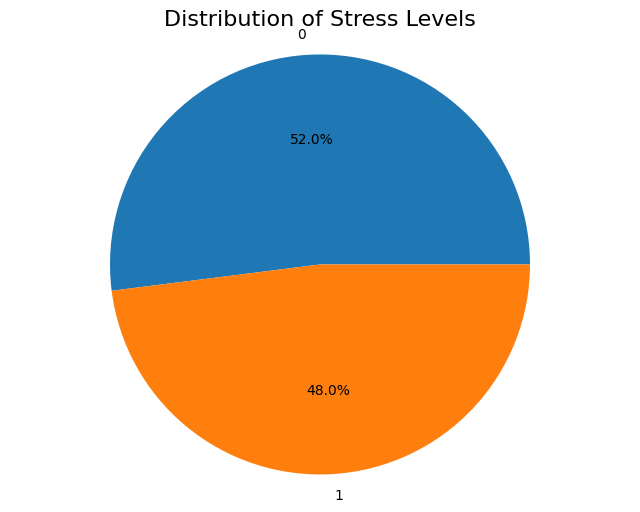

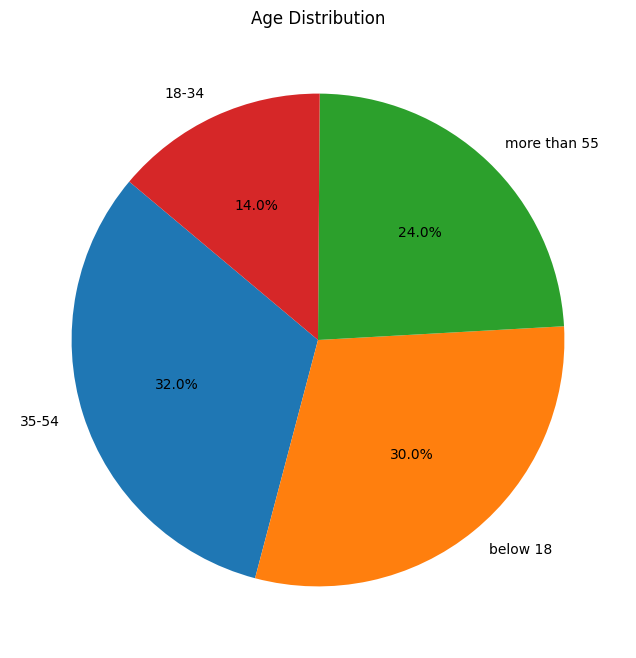

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Define the demographic parameters
ages = ['below 18', '18-34', '35-54', 'more than 55']
genders = ['male', 'female']
ethnicities = ['Hindu', 'Islam', 'Punjabi', 'Jain']
geographic_locations = ['Jharkhand'] + ['Uttar Pradesh', 'Maharashtra', 'Bihar', 'West Bengal', 'Madhya Pradesh', 'Tamil Nadu', 'Rajasthan', 'Karnataka', 'Gujarat', 'Andhra Pradesh', 'Odisha', 'Telangana', 'Kerala', 'Assam', 'Punjab', 'Chhattisgarh', 'Haryana', 'Uttarakhand', 'Himachal Pradesh', 'Tripura', 'Meghalaya', 'Manipur', 'Nagaland', 'Goa', 'Arunachal Pradesh', 'Mizoram', 'Sikkim', 'Delhi', 'Puducherry']
educational_backgrounds = ['10th pass', '12th pass', 'graduate', 'post graduate']

data['Age'] = data['Age'].replace({0: ages[0], 1: ages[1], 2: ages[2], 3: ages[3]})
data['Gender'] = data['Gender'].replace({0: genders[0], 1: genders[1]})
data['Ethnicity'] = data['Ethnicity'].replace({0: ethnicities[0], 1: ethnicities[1], 2: ethnicities[2], 3: ethnicities[3]})
data['Geographic_location'] = data['Geographic_location'].replace({i: geographic_locations[i] for i in range(len(geographic_locations))})
data['Educational_background'] = data['Educational_background'].replace({0: educational_backgrounds[0], 1: educational_backgrounds[1], 2: educational_backgrounds[2], 3: educational_backgrounds[3]})

# Count the number of instances for each stress level
stress_counts = data['Stress'].value_counts()
# Create a pie chart
fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(stress_counts, labels=stress_counts.index, autopct='%1.1f%%')
ax.axis('equal')  # Equal aspect ratio ensures the pie chart is drawn as a circle
ax.set_title('Distribution of Stress Levels', fontsize=16)
plt.show()

# Age distribution
plt.figure(figsize=(8, 8))
gender_counts = data['Age'].value_counts()
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Age Distribution')
plt.show()

# Box Plot
fig = px.box(data, x='Educational_background', y='Stress', color='Geographic_location', title='Stress Levels by Education and Location')
fig.show()

# Violin Plot
fig = px.violin(data, y='Stress', x='Age', color='Ethnicity', title='Distribution of Stress Levels by Age and Ethnicity')
fig.show()

# Sunburst Chart
fig = px.sunburst(data, path=['Ethnicity', 'Geographic_location', 'Educational_background'], values='Stress', title='Hierarchical View of Stress Levels')
fig.show()

# Data Preprocessing

In [ ]:
path = '/content/housewife_dataset/stress_test_dataredblue'  # Replace with the path to your CSV files
all_files = glob.glob(os.path.join(path, "*.csv"))

data_frames = []
for file in all_files:
    df = pd.read_csv(file)
    data_frames.append(df)

# Concatenate all data frames
data = pd.concat(data_frames, axis=0, ignore_index=True)
data

,Timestamp,ECG,EDA,TEMP,CONDITION
0,0.000000,-0.349327,5.000000,37.000000,0
1,0.100334,1.449539,4.985082,37.000630,0
2,0.200669,0.628140,4.986267,37.001261,0
3,0.301003,-1.249250,5.018821,37.001891,0
4,0.401338,-0.706776,5.028773,37.002521,0
...,...,...,...,...,...
44995,89.599332,0.015500,11.863632,37.439204,1
44996,89.699499,-1.361678,11.778900,37.439705,1
44997,89.799666,0.511239,11.701014,37.440208,1
44998,89.899833,0.091206,11.761157,37.440713,1


In [ ]:
# Drop any rows with missing values
data.dropna(inplace=True)

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
data[['ECG', 'EDA', 'TEMP']] = scaler.fit_transform(data[['ECG', 'EDA', 'TEMP']])

# Feature Engineering

| Domain | Feature | Description |
| --- | --- | --- |
| Time-Domain Features | Mean | The average value of the signal. |
|  | Standard Deviation (std) | A measure of the amount of variation or dispersion of a set of values. |
|  | Minimum (min) | The smallest value in the signal. |
|  | Maximum (max) | The largest value in the signal. |
|  | Signal Energy | The total magnitude of the signal, calculated as the sum of the squares of its values. |
|  | Mean Absolute Deviation (MAD) | The average absolute difference between each value and the mean. |
|  | Root Mean Square (RMS) | The square root of the average of the squares of the values. |
|  | Peak-to-Peak (P2P) | The difference between the maximum and minimum values in the signal. |
|  | Zero Crossing Rate | number of zero crossings normalized by the length of the segment |
|  | Shannon Entropy | entropy of unique values |
| Additional Statistical Features | Skewness | only if std > 1e-10 |
|  | Kurtosis | only if std > 1e-10 |
| Frequency-Domain Features (using Welch's method) | Total Power | sum of Pxx |
|  | Frequency with Maximum Power | index of maximum Pxx |
|  | Mean Frequency | mean of f * Pxx normalized by total power, if total power > 0 |
|  | Median Frequency | interpolated frequency at half total power, if total power > 0 |
|  | Spectral Entropy | entropy of Pxx, if total power > 0 |
|  | Spectral Centroid | mean of f * Pxx normalized by total power, if total power > 0 |
| Frequency Band Energy Features: | Delta Band Energy | sum of Pxx in 0.5-4 Hz |
|  | Theta Band Energy | sum of Pxx in 4-8 Hz |
|  | Alpha Band Energy | sum of Pxx in 8-13 Hz |
|  | Beta Band Energy | sum of Pxx in 13-30 Hz |
|  | Gamma Band Energy | sum of Pxx above 30 Hz |
| Time-Frequency Features: | Short-Time Fourier Transform (STFT) Energy | sum of squared magnitudes of Zxx |
|  | Instantaneous Frequency | mean of the instantaneous frequency calculated from the analytic signal |
|  | Continuous Wavelet Transform (CWT) Coefficients Energy | sum of absolute values of CWT coefficients |
|  | Hilbert Transform Energy | sum of absolute values of the Hilbert transform |



Feature Extraction

In [ ]:
from scipy.stats import skew, kurtosis, entropy
from scipy.signal import welch, stft, hilbert, cwt, ricker

# Feature Extraction Function
def extract_features(segment):
    features = []
    for col in segment.columns:
        noisy_segment = segment[col] + np.random.normal(0, 1e-10, segment[col].shape)

        # Time-domain features
        features.append(segment[col].mean())
        features.append(segment[col].std())
        features.append(segment[col].min())
        features.append(segment[col].max())

        # Additional features
        features.append(np.sum(segment[col]**2))  # Signal Energy
        features.append(np.mean(np.abs(segment[col] - np.mean(segment[col]))))  # MAD
        features.append(np.sqrt(np.mean(segment[col]**2)))  # RMS
        features.append(segment[col].max() - segment[col].min())  # P2P

        zero_crossings = np.where(np.diff(np.sign(segment[col])))[0]
        features.append(len(zero_crossings) / float(len(segment[col])))

        value, counts = np.unique(segment[col], return_counts=True)
        features.append(entropy(counts))

        if segment[col].std() > 1e-10:
            features.append(skew(noisy_segment))
            features.append(kurtosis(noisy_segment))
        else:
            features.extend([0, 0])

        # Frequency-domain features using Welch's method
        f, Pxx = welch(segment[col], fs=1.0, nperseg=min(256, len(segment[col])))
        features.append(np.sum(Pxx))  # Total power
        features.append(np.argmax(Pxx))  # Frequency with maximum power

        # Additional frequency-domain features
        total_power = np.sum(Pxx)
        if total_power > 0:
            features.append(np.mean(f * Pxx) / total_power)  # Mean Frequency
            median_freq = np.interp(total_power / 2.0, np.cumsum(Pxx), f)
            features.append(median_freq)  # Median Frequency
            features.append(entropy(Pxx))  # Spectral Entropy
            features.append(np.sum(f * Pxx) / total_power)  # Spectral Centroid
        else:
            features.extend([0, 0, 0, 0])

        features.append(np.sum(Pxx[(f >= 0.5) & (f < 4)]))  # Delta Band Energy
        features.append(np.sum(Pxx[(f >= 4) & (f < 8)]))  # Theta Band Energy
        features.append(np.sum(Pxx[(f >= 8) & (f < 13)]))  # Alpha Band Energy
        features.append(np.sum(Pxx[(f >= 13) & (f < 30)]))  # Beta Band Energy
        features.append(np.sum(Pxx[(f >= 30)]))  # Gamma Band Energy

        # Time-Frequency features
        f_stft, t_stft, Zxx = stft(segment[col], nperseg=min(256, len(segment[col])))
        features.append(np.sum(np.abs(Zxx)**2))  # STFT Energy

        analytic_signal = hilbert(segment[col])
        instantaneous_frequency = np.diff(np.unwrap(np.angle(analytic_signal)))
        features.append(np.mean(instantaneous_frequency))  # Instantaneous Frequency

        widths = np.arange(1, 31)
        cwt_matr = cwt(segment[col], ricker, widths)
        features.append(np.sum(np.abs(cwt_matr)))  # Wavelet Coefficients Energy
        features.append(np.sum(np.abs(hilbert(segment[col]))))  # Hilbert Transform Energy

    return features


Sequence Preparation with Feature Extraction : Assuming each subject's data is sequentially organized we are creating sequences for each subject

In [ ]:
def create_sequences_with_features(data, sequence_length):
    sequences = []
    labels = []
    for i in range(0, len(data) - sequence_length):
        segment = data[['ECG', 'EDA', 'TEMP']].iloc[i:i + sequence_length]
        label = data['CONDITION'].iloc[i + sequence_length - 1]

        # Extract features from the segment
        features = extract_features(segment)
        sequences.append(features)
        labels.append(label)

    return np.array(sequences), np.array(labels)

Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

sequence_length = 50
X, y = create_sequences_with_features(data, sequence_length)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Selection

• Min-Redundancy-Max-Relevance (mRMR)

• Multi-Cluster Feature Selection (MCFS) method

Min-Redundancy-Max-Relevance (mRMR)

In [ ]:
from pymrmr import mRMR

def mrmr_feature_selection(X_train, y_train, k):
    feature_names = [f'feature_{i}' for i in range(X_train.shape[1])]
    X_train_df = pd.DataFrame(X_train, columns=feature_names)
    y_train_df = pd.Series(y_train, name='target')
    data = pd.concat([X_train_df, y_train_df], axis=1)

    selected_features = mRMR(data, 'MIQ', k)
    selected_feature_indices = [int(f.split('_')[1]) for f in selected_features]

    return selected_feature_indices

c = 15  # Number of top features to select
selected_indices = mrmr_feature_selection(X_train, y_train, c)

X_train_selected = X_train[:, selected_indices]
X_test_selected = X_test[:, selected_indices]

# Classification Models

Classification ML :  SVM,  RF,  DT, extreme boosting, MNB, boot aggregation, Gaussian NB, MLPNN,RBFNN

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

models = {
    'Simple Bagging': (BaggingClassifier(random_state=42), {'n_estimators': [10, 50, 100], 'max_features': [0.5, 0.7, 1.0]}),
    'Bagging SVM': (BaggingClassifier(base_estimator=SVC(), random_state=42), {'n_estimators': [10, 50, 100]}),
    'Bagging RF': (BaggingClassifier(base_estimator=RandomForestClassifier(random_state=42), random_state=42), {'n_estimators': [10, 50, 100]}),
    'Bagging DT': (BaggingClassifier(base_estimator=DecisionTreeClassifier(random_state=42), random_state=42), {'n_estimators': [10, 50, 100, 200], 'max_features': [0.5, 0.7, 1.0]}),
    'XGBoost': (XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42), {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.1]}),
    'Gradient Boosting': (GradientBoostingClassifier(random_state=42), {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.1], 'max_features': [0.5, 0.7, 1.0],  'subsample': [0.5, 0.7, 1.0]})
}

Training ML Models:   0%|          | 0/6 [00:00<?, ?it/s]

Perfomance Metrics for Simple Bagging
Simple Bagging Best Params: {'max_features': 0.5, 'n_estimators': 10}
Simple Bagging Accuracy: 1.00
Simple Bagging Precision: 1.00
Simple Bagging Recall: 1.00
Simple Bagging F1 Score: 1.00


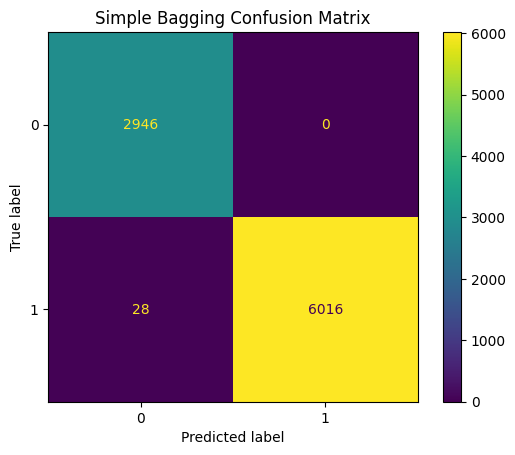

Training ML Models:  17%|█▋        | 1/6 [02:33<12:49, 153.80s/it]

Perfomance Metrics for Bagging SVM
Bagging SVM Best Params: {'n_estimators': 10}
Bagging SVM Accuracy: 0.67
Bagging SVM Precision: 0.70
Bagging SVM Recall: 0.67
Bagging SVM F1 Score: 0.55


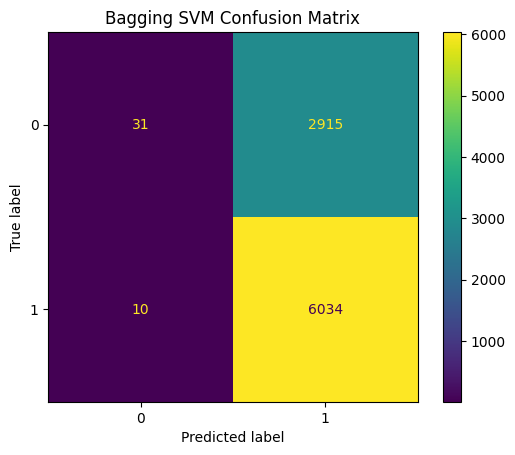

Training ML Models:  33%|███▎      | 2/6 [04:21<08:27, 126.93s/it]

Perfomance Metrics for Bagging RF
Bagging RF Best Params: {'n_estimators': 10}
Bagging RF Accuracy: 1.00
Bagging RF Precision: 1.00
Bagging RF Recall: 1.00
Bagging RF F1 Score: 1.00


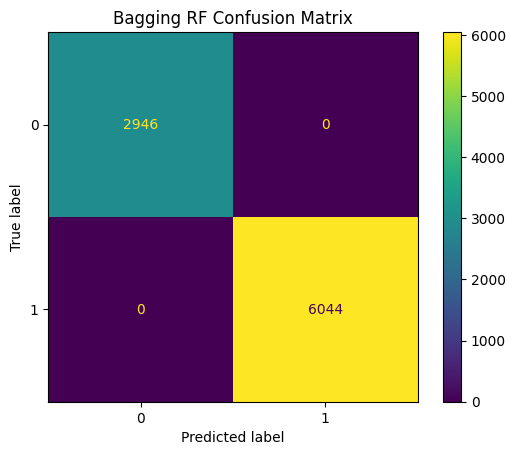

Training ML Models:  50%|█████     | 3/6 [31:06<40:05, 801.68s/it]

Perfomance Metrics for Bagging DT
Bagging DT Best Params: {'max_features': 0.5, 'n_estimators': 10}
Bagging DT Accuracy: 1.00
Bagging DT Precision: 1.00
Bagging DT Recall: 1.00
Bagging DT F1 Score: 1.00


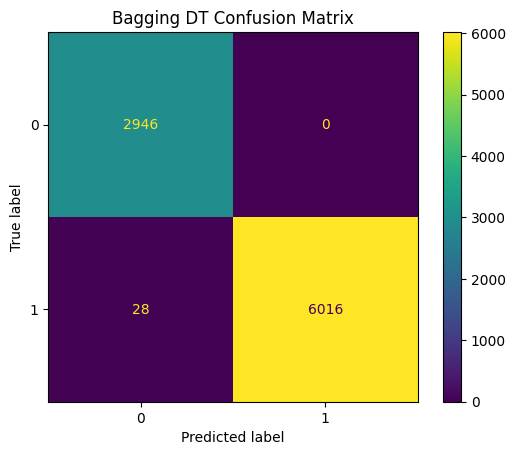

Training ML Models:  67%|██████▋   | 4/6 [36:49<20:40, 620.40s/it]

Perfomance Metrics for XGBoost
XGBoost Best Params: {'learning_rate': 0.01, 'n_estimators': 100}
XGBoost Accuracy: 0.96
XGBoost Precision: 0.96
XGBoost Recall: 0.96
XGBoost F1 Score: 0.96


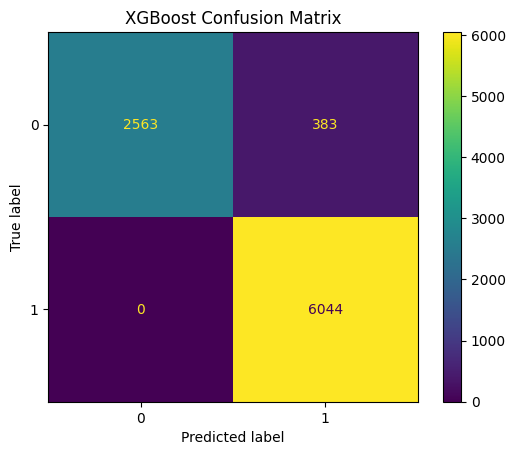

Training ML Models:  83%|████████▎ | 5/6 [37:00<06:40, 400.79s/it]

Perfomance Metrics for Gradient Boosting
Gradient Boosting Best Params: {'learning_rate': 0.01, 'max_features': 0.5, 'n_estimators': 100, 'subsample': 0.5}
Gradient Boosting Accuracy: 1.00
Gradient Boosting Precision: 1.00
Gradient Boosting Recall: 1.00
Gradient Boosting F1 Score: 1.00


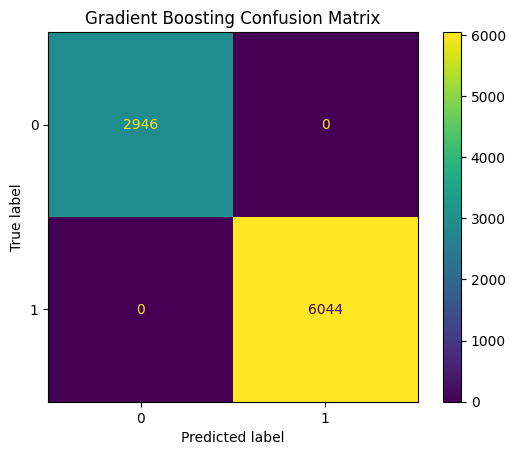

Training ML Models: 100%|██████████| 6/6 [1:09:20<00:00, 693.42s/it]


In [ ]:
from tqdm import tqdm
results = []

for name, (model, params) in tqdm(models.items(), desc="Training ML Models"):
    grid_search = GridSearchCV(model, params, cv=5, scoring='accuracy')
    grid_search.fit(scaler.fit_transform(X_train_selected), y_train)
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test_selected)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)

    results.append({
        'Model': name,
        'Best Params': grid_search.best_params_,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })

    print(f'Perfomance Metrics for {name}')
    print(f'{name} Best Params: {grid_search.best_params_}')
    print(f'{name} Accuracy: {accuracy:.2f}')
    print(f'{name} Precision: {precision:.2f}')
    print(f'{name} Recall: {recall:.2f}')
    print(f'{name} F1 Score: {f1:.2f}')

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f'{name} Confusion Matrix')
    plt.show()

# Deep Learning Models - LSTM & RNN

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, LSTM, SimpleRNN, Dropout
from tensorflow.keras.callbacks import EarlyStopping

deep_learning_models = {
    'LSTM': Sequential([
        LSTM(50, activation='relu', input_shape=(X_train_selected.shape[1], 1)),
        Dropout(0.5),
        Flatten(),
        Dense(1, activation='sigmoid')
    ]),
    'RNN': Sequential([
        SimpleRNN(50, activation='relu', input_shape=(X_train_selected.shape[1], 1)),
        Dense(1, activation='sigmoid')
    ])
}

281/281 [==============================] - 1s 4ms/step
LSTM Accuracy: 1.00
LSTM Precision: 1.00
LSTM Recall: 1.00
LSTM F1 Score: 1.00


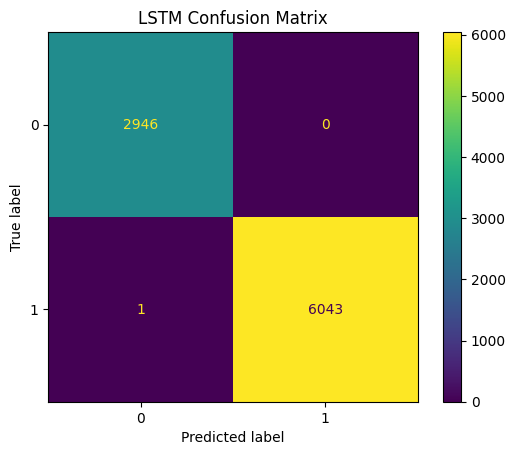

281/281 [==============================] - 1s 3ms/step
RNN Accuracy: 1.00
RNN Precision: 1.00
RNN Recall: 1.00
RNN F1 Score: 1.00


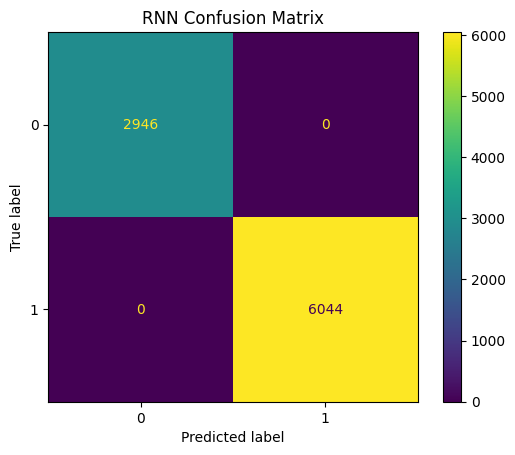

In [ ]:
# Deep Learning Models
X_train_selected_dl = X_train_selected.reshape((X_train_selected.shape[0], X_train_selected.shape[1], 1))
X_test_selected_dl = X_test_selected.reshape((X_test_selected.shape[0], X_test_selected.shape[1], 1))

for name, model in deep_learning_models.items():
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    model.fit(X_train_selected_dl, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=[early_stopping], verbose=0)
    y_pred = (model.predict(X_test_selected_dl) > 0.5).astype(int)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)

    results.append({
        'Model': name,
        'Best Params': 'N/A',
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })

    print(f'{name} Accuracy: {accuracy:.2f}')
    print(f'{name} Precision: {precision:.2f}')
    print(f'{name} Recall: {recall:.2f}')
    print(f'{name} F1 Score: {f1:.2f}')

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f'{name} Confusion Matrix')
    plt.show()

# Print Summary
summary_df = pd.DataFrame(results)

In [ ]:
from tabulate import tabulate
headers = ["Model", "Best Params", "Accuracy", "Precision", "Recall", "F1 Score"]
print(tabulate(summary_df, headers, tablefmt="pretty"))

+---+-------------------+-------------------------------------------------------------------------------------+--------------------+--------------------+--------------------+--------------------+
|   |       Model       |                                     Best Params                                     |      Accuracy      |     Precision      |       Recall       |      F1 Score      |
+---+-------------------+-------------------------------------------------------------------------------------+--------------------+--------------------+--------------------+--------------------+
| 0 |  Simple Bagging   |                      {'max_features': 0.5, 'n_estimators': 10}                      | 0.9968854282536151 | 0.9969147517266814 | 0.9968854282536151 | 0.9968891782058155 |
| 1 |    Bagging SVM    |                                {'n_estimators': 10}                                 | 0.6746384872080089 | 0.7010815098133145 | 0.6746384872080089 | 0.5479442400578682 |
| 2 |    Bagging RF 

# Classification after MCFS feature selection method

In [ ]:
from sklearn.model_selection import train_test_split

sequence_length = 50
X, y = create_sequences_with_features(data, sequence_length)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from skfeature.function.sparse_learning_based import MCFS

num_clusters = 5
num_selected_features = 15  # Number of top features to select

W = MCFS.mcfs(X_test_selected, n_selected_features=num_selected_features, n_clusters=num_clusters)
# Get the selected features
selected_features = X_train[:, W]

# Print the indices of selected features
print("Indices of selected features:", W)
print("Selected features:")
print(selected_features)

from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestRegressor

selector = SelectKBest(mutual_info_classif, k=15)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

Indices of selected features: [ 1  7  6  8  0 11  2 13  4 14 12  3  5  9 10]
Selected features:
[[ 0.22867696  0.76716958  0.59727427 ...  0.19247691  3.91202301
  -0.18920773]
 [ 0.24608006  0.92244616  0.59741003 ...  0.19993603  3.91202301
   0.02797029]
 [ 0.22870723  0.80298511  0.58567385 ...  0.19476931  3.91202301
  -0.13043126]
 ...
 [ 0.22689169  0.8849765   0.59012871 ...  0.18965372  3.91202301
  -0.10749458]
 [ 0.23000328  0.88617331  0.59251982 ...  0.19952956  3.91202301
   0.11367042]
 [ 0.22495759  0.79577906  0.59603691 ...  0.18964466  3.91202301
  -0.24950373]]


Training ML Models:   0%|          | 0/6 [00:00<?, ?it/s]

Perfomance Metrics for Simple Bagging
Simple Bagging Best Params: {'max_features': 0.5, 'n_estimators': 10}
Simple Bagging Accuracy: 0.54
Simple Bagging Precision: 0.81
Simple Bagging Recall: 0.54
Simple Bagging F1 Score: 0.51


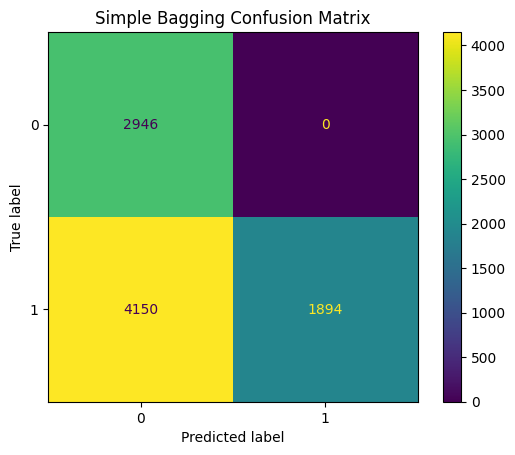

Training ML Models:  17%|█▋        | 1/6 [01:45<08:45, 105.09s/it]

Perfomance Metrics for Bagging SVM
Bagging SVM Best Params: {'n_estimators': 10}
Bagging SVM Accuracy: 0.67
Bagging SVM Precision: 0.45
Bagging SVM Recall: 0.67
Bagging SVM F1 Score: 0.54


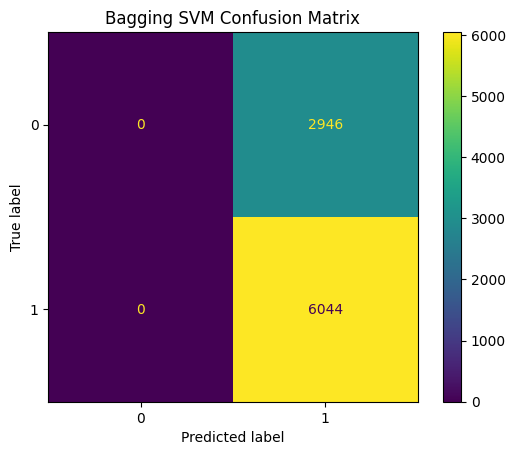

Training ML Models:  33%|███▎      | 2/6 [09:17<20:38, 309.63s/it]

Perfomance Metrics for Bagging RF
Bagging RF Best Params: {'n_estimators': 10}
Bagging RF Accuracy: 0.98
Bagging RF Precision: 0.98
Bagging RF Recall: 0.98
Bagging RF F1 Score: 0.98


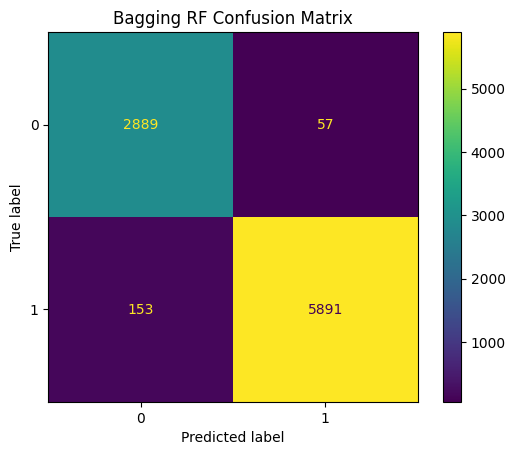

Training ML Models:  50%|█████     | 3/6 [28:08<34:13, 684.44s/it]

Perfomance Metrics for Bagging DT
Bagging DT Best Params: {'max_features': 0.5, 'n_estimators': 10}
Bagging DT Accuracy: 0.54
Bagging DT Precision: 0.81
Bagging DT Recall: 0.54
Bagging DT F1 Score: 0.51


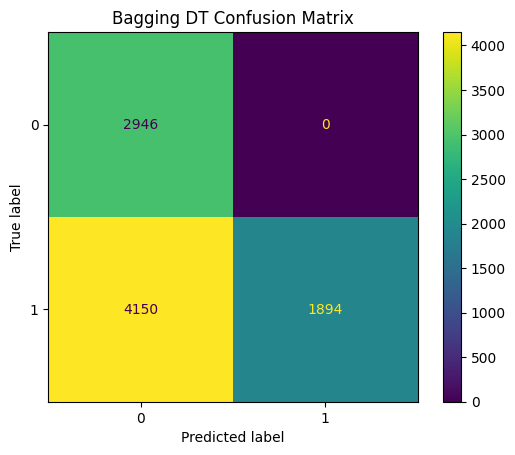

Training ML Models:  67%|██████▋   | 4/6 [32:11<17:00, 510.23s/it]

Perfomance Metrics for XGBoost
XGBoost Best Params: {'learning_rate': 0.01, 'n_estimators': 100}
XGBoost Accuracy: 0.76
XGBoost Precision: 0.82
XGBoost Recall: 0.76
XGBoost F1 Score: 0.71


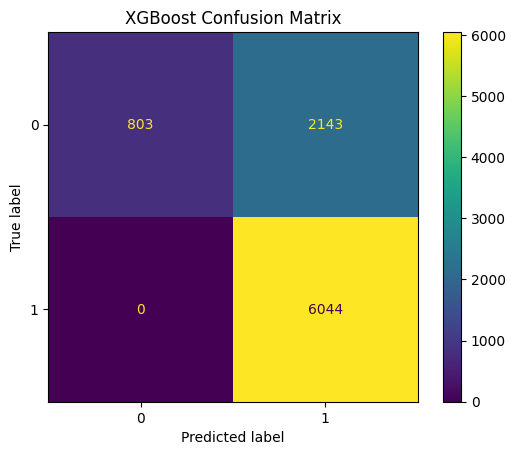

Training ML Models:  83%|████████▎ | 5/6 [32:24<05:30, 330.93s/it]

Perfomance Metrics for Gradient Boosting
Gradient Boosting Best Params: {'learning_rate': 0.01, 'max_features': 0.5, 'n_estimators': 100, 'subsample': 0.5}
Gradient Boosting Accuracy: 0.98
Gradient Boosting Precision: 0.98
Gradient Boosting Recall: 0.98
Gradient Boosting F1 Score: 0.98


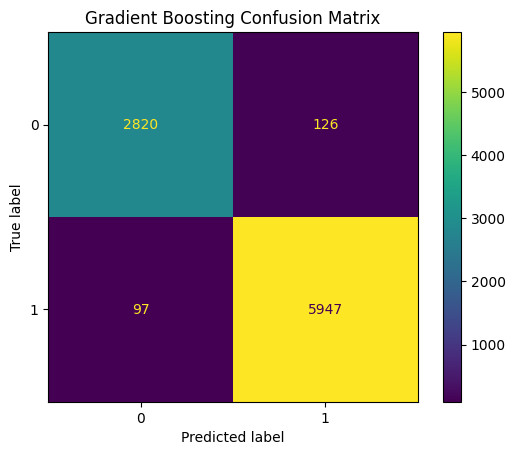

Training ML Models: 100%|██████████| 6/6 [57:00<00:00, 570.07s/it]


In [ ]:
from tqdm import tqdm
results = []

for name, (model, params) in tqdm(models.items(), desc="Training ML Models"):
    grid_search = GridSearchCV(model, params, cv=5, scoring='accuracy')
    grid_search.fit(scaler.fit_transform(X_train_selected), y_train)
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test_selected)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)

    results.append({
        'Model': name,
        'Best Params': grid_search.best_params_,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })

    print(f'Perfomance Metrics for {name}')
    print(f'{name} Best Params: {grid_search.best_params_}')
    print(f'{name} Accuracy: {accuracy:.2f}')
    print(f'{name} Precision: {precision:.2f}')
    print(f'{name} Recall: {recall:.2f}')
    print(f'{name} F1 Score: {f1:.2f}')

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f'{name} Confusion Matrix')
    plt.show()

281/281 [==============================] - 1s 4ms/step
LSTM Accuracy: 1.00
LSTM Precision: 1.00
LSTM Recall: 1.00
LSTM F1 Score: 1.00


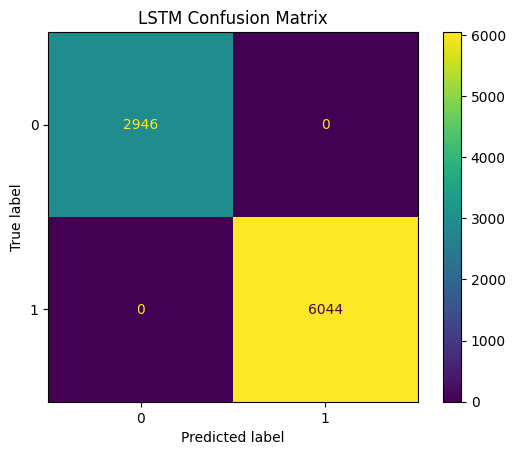

281/281 [==============================] - 1s 2ms/step
RNN Accuracy: 1.00
RNN Precision: 1.00
RNN Recall: 1.00
RNN F1 Score: 1.00


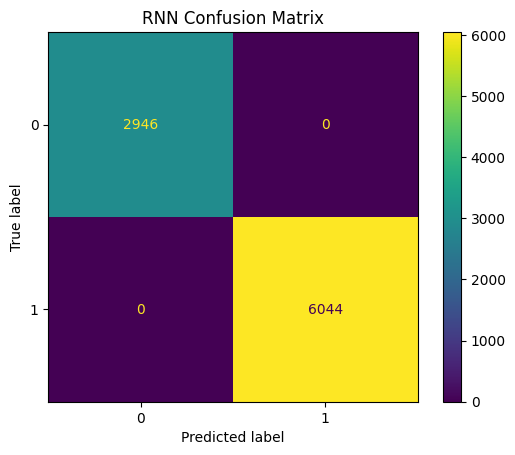

In [ ]:
# Deep Learning Models
X_train_selected_dl = X_train_selected.reshape((X_train_selected.shape[0], X_train_selected.shape[1], 1))
X_test_selected_dl = X_test_selected.reshape((X_test_selected.shape[0], X_test_selected.shape[1], 1))

for name, model in deep_learning_models.items():
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    model.fit(X_train_selected_dl, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=[early_stopping], verbose=0)
    y_pred = (model.predict(X_test_selected_dl) > 0.5).astype(int)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)

    results.append({
        'Model': name,
        'Best Params': 'N/A',
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })

    print(f'{name} Accuracy: {accuracy:.2f}')
    print(f'{name} Precision: {precision:.2f}')
    print(f'{name} Recall: {recall:.2f}')
    print(f'{name} F1 Score: {f1:.2f}')

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f'{name} Confusion Matrix')
    plt.show()

# Print Summary
summary_df = pd.DataFrame(results)

In [ ]:
from tabulate import tabulate
headers = ["Model", "Best Params", "Accuracy", "Precision", "Recall", "F1 Score"]
print(tabulate(summary_df, headers, tablefmt="pretty"))

+---+-------------------+-------------------------------------------------------------------------------------+--------------------+---------------------+--------------------+--------------------+
|   |       Model       |                                     Best Params                                     |      Accuracy      |      Precision      |       Recall       |      F1 Score      |
+---+-------------------+-------------------------------------------------------------------------------------+--------------------+---------------------+--------------------+--------------------+
| 0 |  Simple Bagging   |                      {'max_features': 0.5, 'n_estimators': 10}                      | 0.5383759733036707 | 0.8083505661432658  | 0.5383759733036707 | 0.5130934200957903 |
| 1 |    Bagging SVM    |                                {'n_estimators': 10}                                 | 0.6723025583982203 | 0.45199073002879236 | 0.6723025583982203 | 0.5405609502406337 |
| 2 |    Baggin